In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
class Laberinto:
    def __init__(self):
        self.laberinto = np.array([[0, 0, 0, 1, 0],
                                    [1, 1, 0, 1, 0],
                                    [0, 0, 0, 0, 0],
                                    [0, 1, 1, 1, 1],
                                    [0, 0, 0, 1, 0]])
        self.estado_inicial = (0, 0)
        self.estado_objetivo = (4, 4)
        self.acciones = ['arriba', 'abajo', 'izquierda', 'derecha']
        self.estado_actual = self.estado_inicial

    def reset(self):
        self.estado_actual = self.estado_inicial
        return self.estado_actual

    def step(self, accion):
        fila, col = self.estado_actual
        if accion == 'arriba':
            nueva_fila, nueva_col = fila - 1, col
        elif accion == 'abajo':
            nueva_fila, nueva_col = fila + 1, col
        elif accion == 'izquierda':
            nueva_fila, nueva_col = fila, col - 1
        elif accion == 'derecha':
            nueva_fila, nueva_col = fila, col + 1
        else:
            print (f"Acción inválida: {accion}")
            
        filas_max, cols_max = self.laberinto.shape
        
        if (nueva_fila < 0 or nueva_fila >= filas_max or nueva_col < 0 or nueva_col >= cols_max):
            # Penalizacion por intentar salir del laberinto
            recompensa = -2
            terminado = False
        elif self.laberinto[nueva_fila, nueva_col] == 1:
            # penalizacion por intentar moverse a una pared
            recompensa = -2
            terminado = False
        else:
            self.estado_actual = (nueva_fila, nueva_col)
            if self.estado_actual == self.estado_objetivo:
                # Cuanod llega a la meta
                recompensa = 10
                terminado = True
            else:
                # Cada paso quita -1
                recompensa = -1
                terminado = False

        return self.estado_actual, recompensa, terminado

In [ ]:
class Agente:
    def __init__(self, filas, columnas, acciones, alpha=0.1, gamma=0.99):
        self.acciones = acciones
        self.num_acciones = len(acciones)
        self.alpha = alpha 
        self.gamma = gamma      
        
        self.accion_texto = {act: idx for idx, act in enumerate(acciones)}
        
        self.Q = np.zeros((filas, columnas, self.num_acciones))
        self.N = np.zeros((filas, columnas, self.num_acciones))
        self.t_total = np.zeros((filas, columnas))

    def actualizar(self, estado, accion, recompensa, proximo_estado, terminado):
        f, c = estado
        nf, nc = proximo_estado
        idx_accion = self.accion_texto[accion]
        
        # Registrar la acción tomada
        self.N[f, c, idx_accion] += 1
        if terminado:
            target = recompensa
        else:
            target = recompensa + self.gamma * np.max(self.Q[nf, nc, :])
        self.Q[f, c, idx_accion] += self.alpha * (target - self.Q[f, c, idx_accion])

In [19]:
env = Laberinto()
filas, columnas = env.laberinto.shape
agente = Agente(filas=filas, columnas=columnas, acciones=env.acciones)

episodios = 1000
c = 0.1
historial_recompensas = []

print("Iniciando entrenamiento")

for episodio in range(episodios):
    estado = env.reset()
    terminado = False
    recompensa_acumulada = 0
    pasos = 0
    
    while not terminado and pasos < 200:
        f, c = estado
        agente.t_total[f, c] += 1
        
        valores_ucb = np.zeros(len(env.acciones))
        
        for idx, act in enumerate(env.acciones):
            if agente.N[f, c, idx] == 0:
                valores_ucb[idx] = np.inf
            else:
                explotacion = agente.Q[f, c, idx]
                exploracion = c * np.sqrt(np.log(agente.t_total[f, c]) / agente.N[f, c, idx])
                valores_ucb[idx] = explotacion + exploracion
        
        idx_seleccionado = np.argmax(valores_ucb)
        accion = env.acciones[idx_seleccionado]
        
        proximo_estado, recompensa, terminado = env.step(accion)
        
        agente.actualizar(estado, accion, recompensa, proximo_estado, terminado)
        
        estado = proximo_estado
        recompensa_acumulada += recompensa
        pasos += 1
        
    historial_recompensas.append(recompensa_acumulada)

print("¡Entrenamiento completado!")

Iniciando entrenamiento
¡Entrenamiento completado!


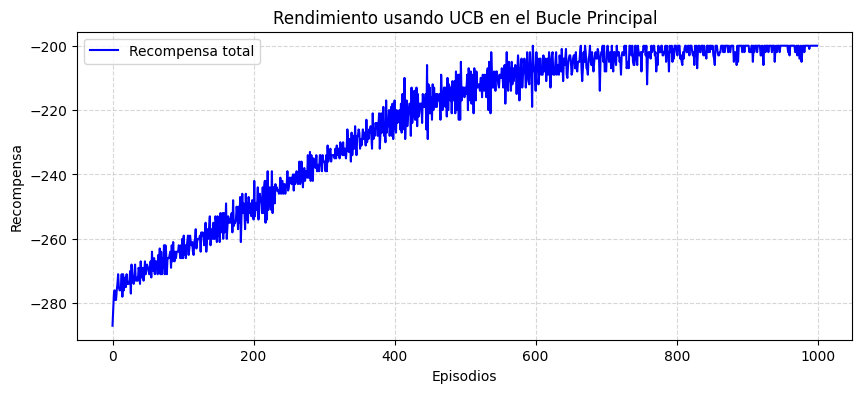


Explotacion pura
Ruta mas corta aprendida: [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 1), (4, 2), (4, 1), (4, 2), (4, 1), (4, 2), (4, 1), (4, 2), (4, 1)]


In [20]:
plt.figure(figsize=(10, 4))
plt.plot(historial_recompensas, color='blue', label='Recompensa total')
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Rendimiento usando UCB en el Bucle Principal')
plt.xlabel('Episodios')
plt.ylabel('Recompensa')
plt.legend()
plt.show()

# Fase de Explotación Pura para ver la ruta más corta aprendida
print("\nExplotacion pura")
estado = env.reset()
terminado = False
ruta_optima = [estado]

while not terminado and len(ruta_optima) < 20:
    f, c = estado
    idx_optimo = np.argmax(agente.Q[f, c, :])
    accion_optima = env.acciones[idx_optimo]
    estado, _, terminado = env.step(accion_optima)
    ruta_optima.append(estado)

print(f"Ruta mas corta aprendida: {ruta_optima}")